<a href="https://colab.research.google.com/github/EmiRoberti77/YOLO11_colac/blob/main/Emi_potholes_custom_data_set_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import locale
locale.getpreferredencoding = lambda:"UTF-8"

In [2]:
!pip install ultralytics
!pip install opencv-python

In [4]:
from ultralytics import YOLO
from IPython.display import Image

In [5]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="4R5KV0K430xAvtMVIfvP")
project = rf.workspace("oaix").project("potholes-detection-segmentation-8akyx")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Potholes-Detection-Segmentation-1 in yolov11:: 100%|██████████| 1574/1574 [00:00<00:00, 6019.37it/s]


In [6]:
dataset.location

'/content/Potholes-Detection-Segmentation-1'

In [8]:
#Load the YOLO11-Seg Model
model = YOLO("yolo11s-seg.pt")

DO NOT Forget to update the data.yaml file that has been downloaded with the data and upadte path paths to where the data is
```yaml
train: /content/Potholes-Detection-Segmentation-1/train/images
val: /content/Potholes-Detection-Segmentation-1/valid/images
test: /content/Potholes-Detection-Segmentation-1/test/images

nc: 1
names: ['Pothole']

roboflow:
  workspace: oaix
  project: potholes-detection-segmentation-8akyx
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/oaix/potholes-detection-segmentation-8akyx/dataset/1
```

In [9]:
#Train the Model on a Custom Dataset pointing YOLO to the data.yaml file
results = model.train(task="segment", mode="train", data="/content/Potholes-Detection-Segmentation-1/data.yaml", epochs=50)

Ultralytics 8.3.162 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Potholes-Detection-Segmentation-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots

100%|██████████| 755k/755k [00:00<00:00, 19.7MB/s]

Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.block.C3k2            [256, 256, 1, True]           
  7                  -1  1   1180672  ultralytics

 23        [16, 19, 22]  1   1474291  ultralytics.nn.modules.head.Segment          [1, 32, 128, [128, 256, 512]] 
YOLO11s-seg summary: 203 layers, 10,082,675 parameters, 10,082,659 gradients, 35.6 GFLOPs

Transferred 555/561 items from pretrained weights
Freezing layer 'model.23.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


100%|██████████| 5.35M/5.35M [00:00<00:00, 81.5MB/s]


...

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):  40%|████      | 2/5 [00:01<00:02,  1.08it/s]

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:06<00:00,  1.20s/it]


                   all        157        443      0.919      0.849      0.943      0.662      0.917      0.847      0.938      0.623
Speed: 0.5ms preprocess, 7.9ms inference, 0.0ms loss, 9.4ms postprocess per image
Results saved to runs/segment/train


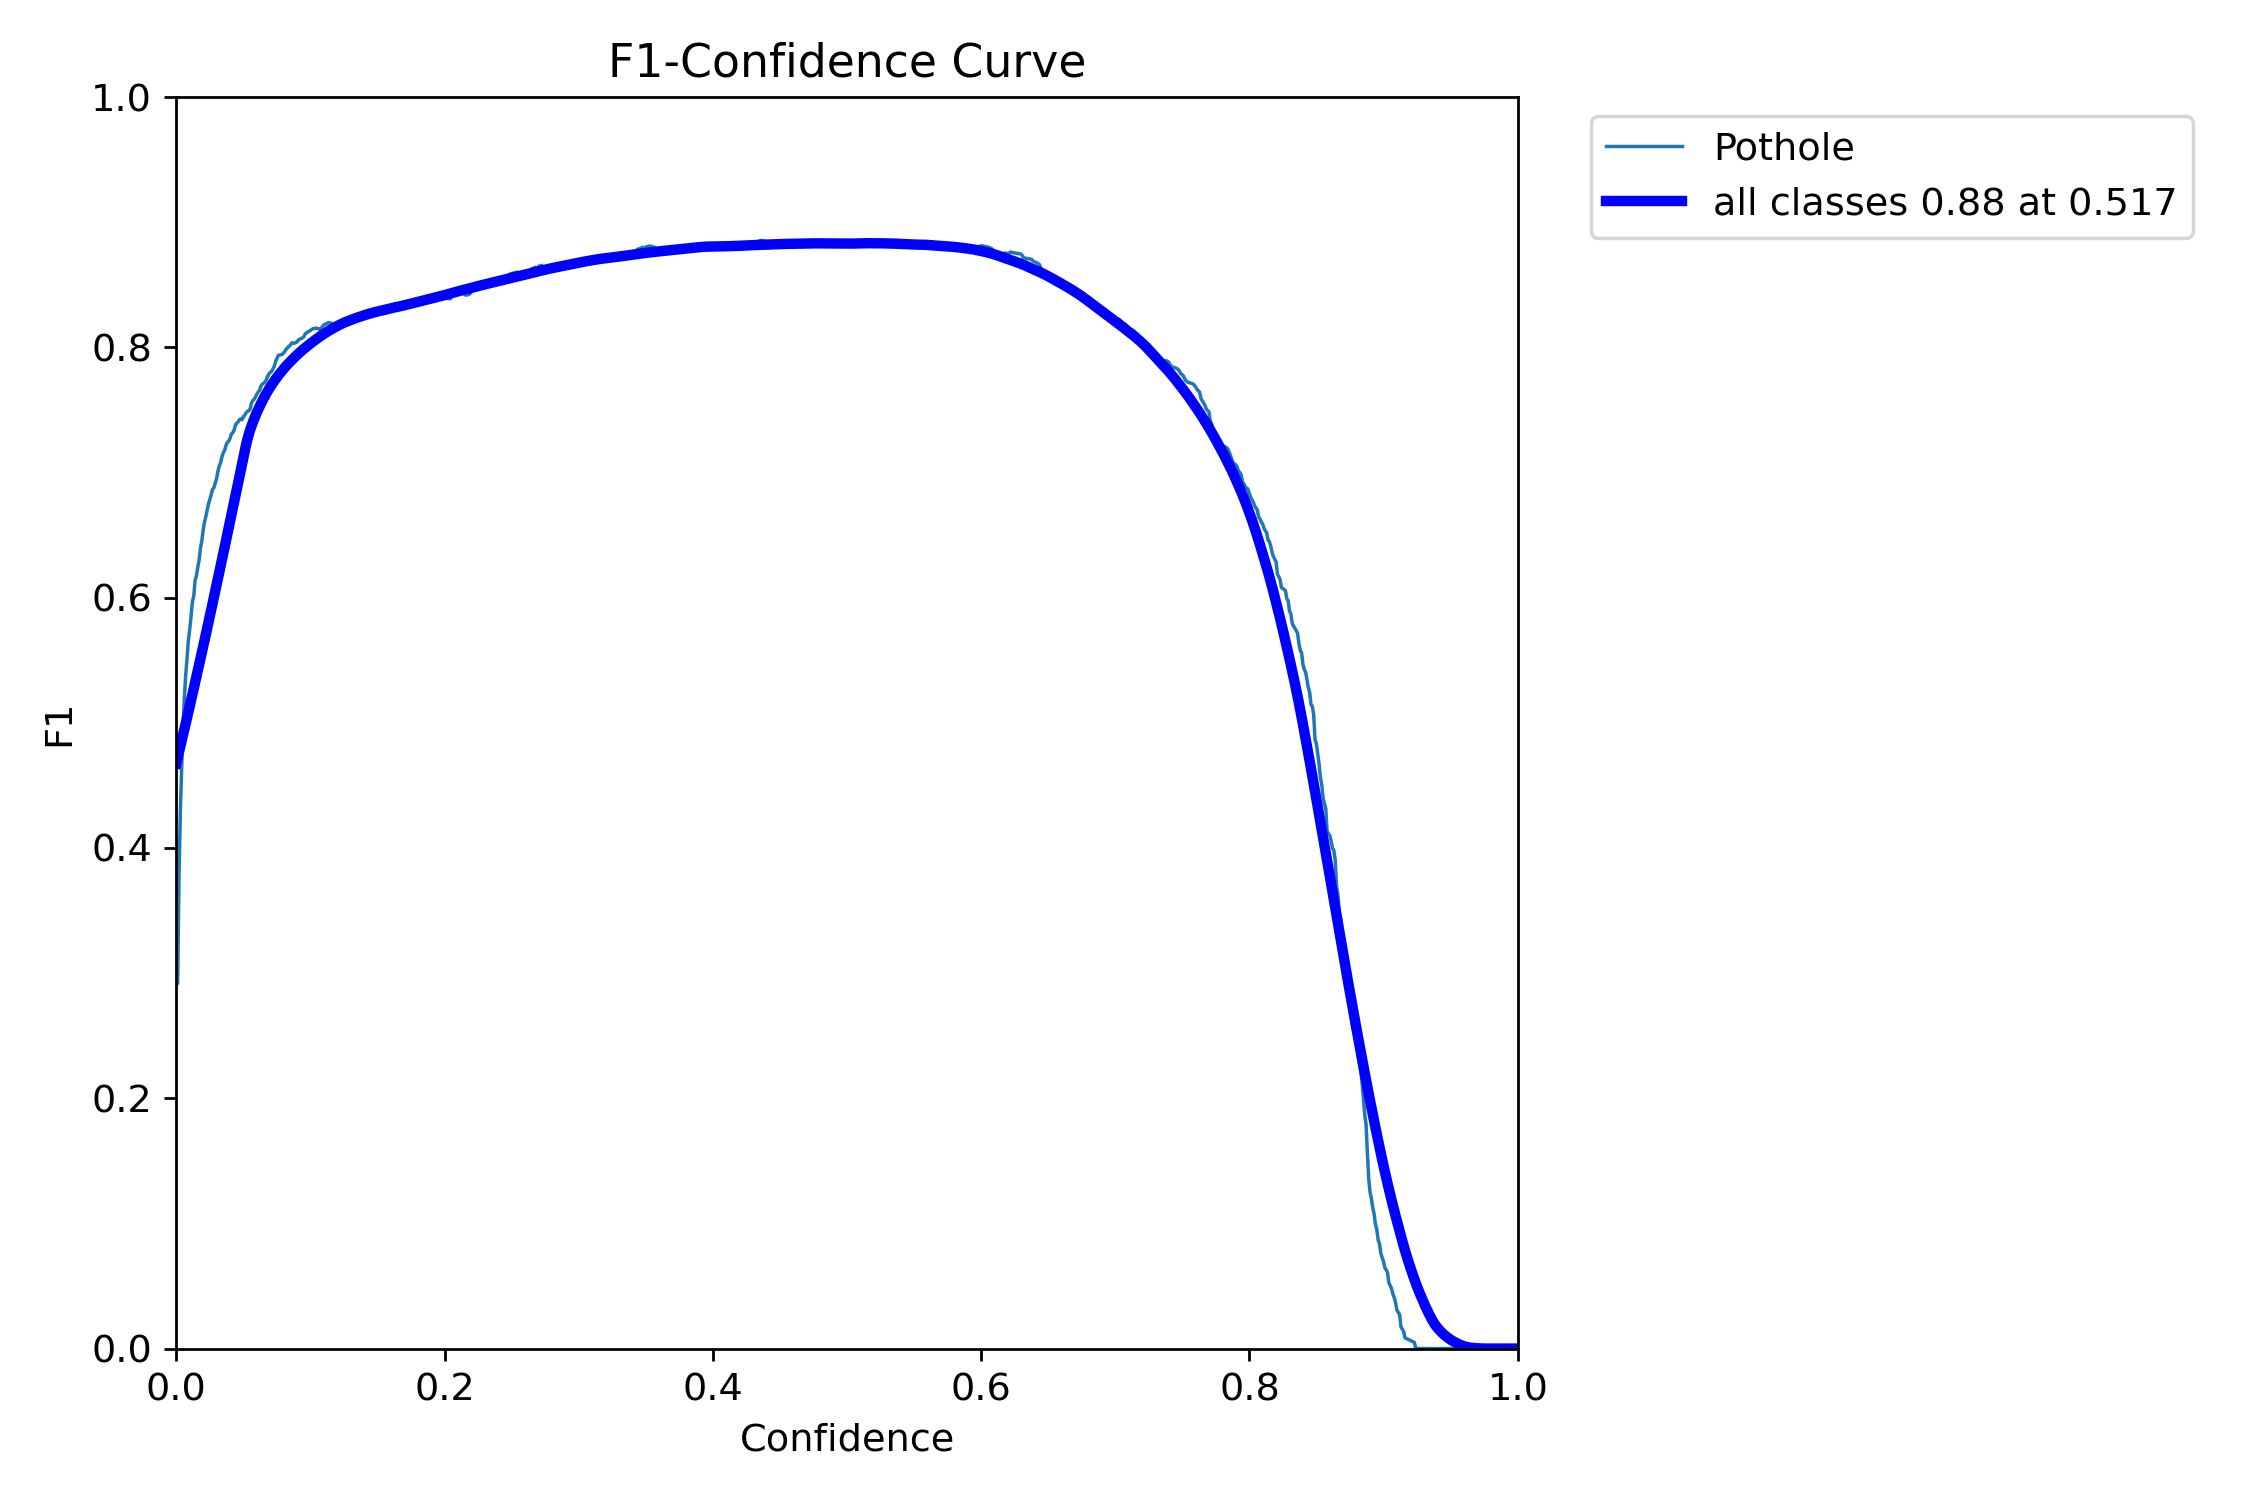

In [10]:
# Model Performance
prefix = '/content/runs/segment/train/'
Image(prefix + "BoxF1_curve.png")

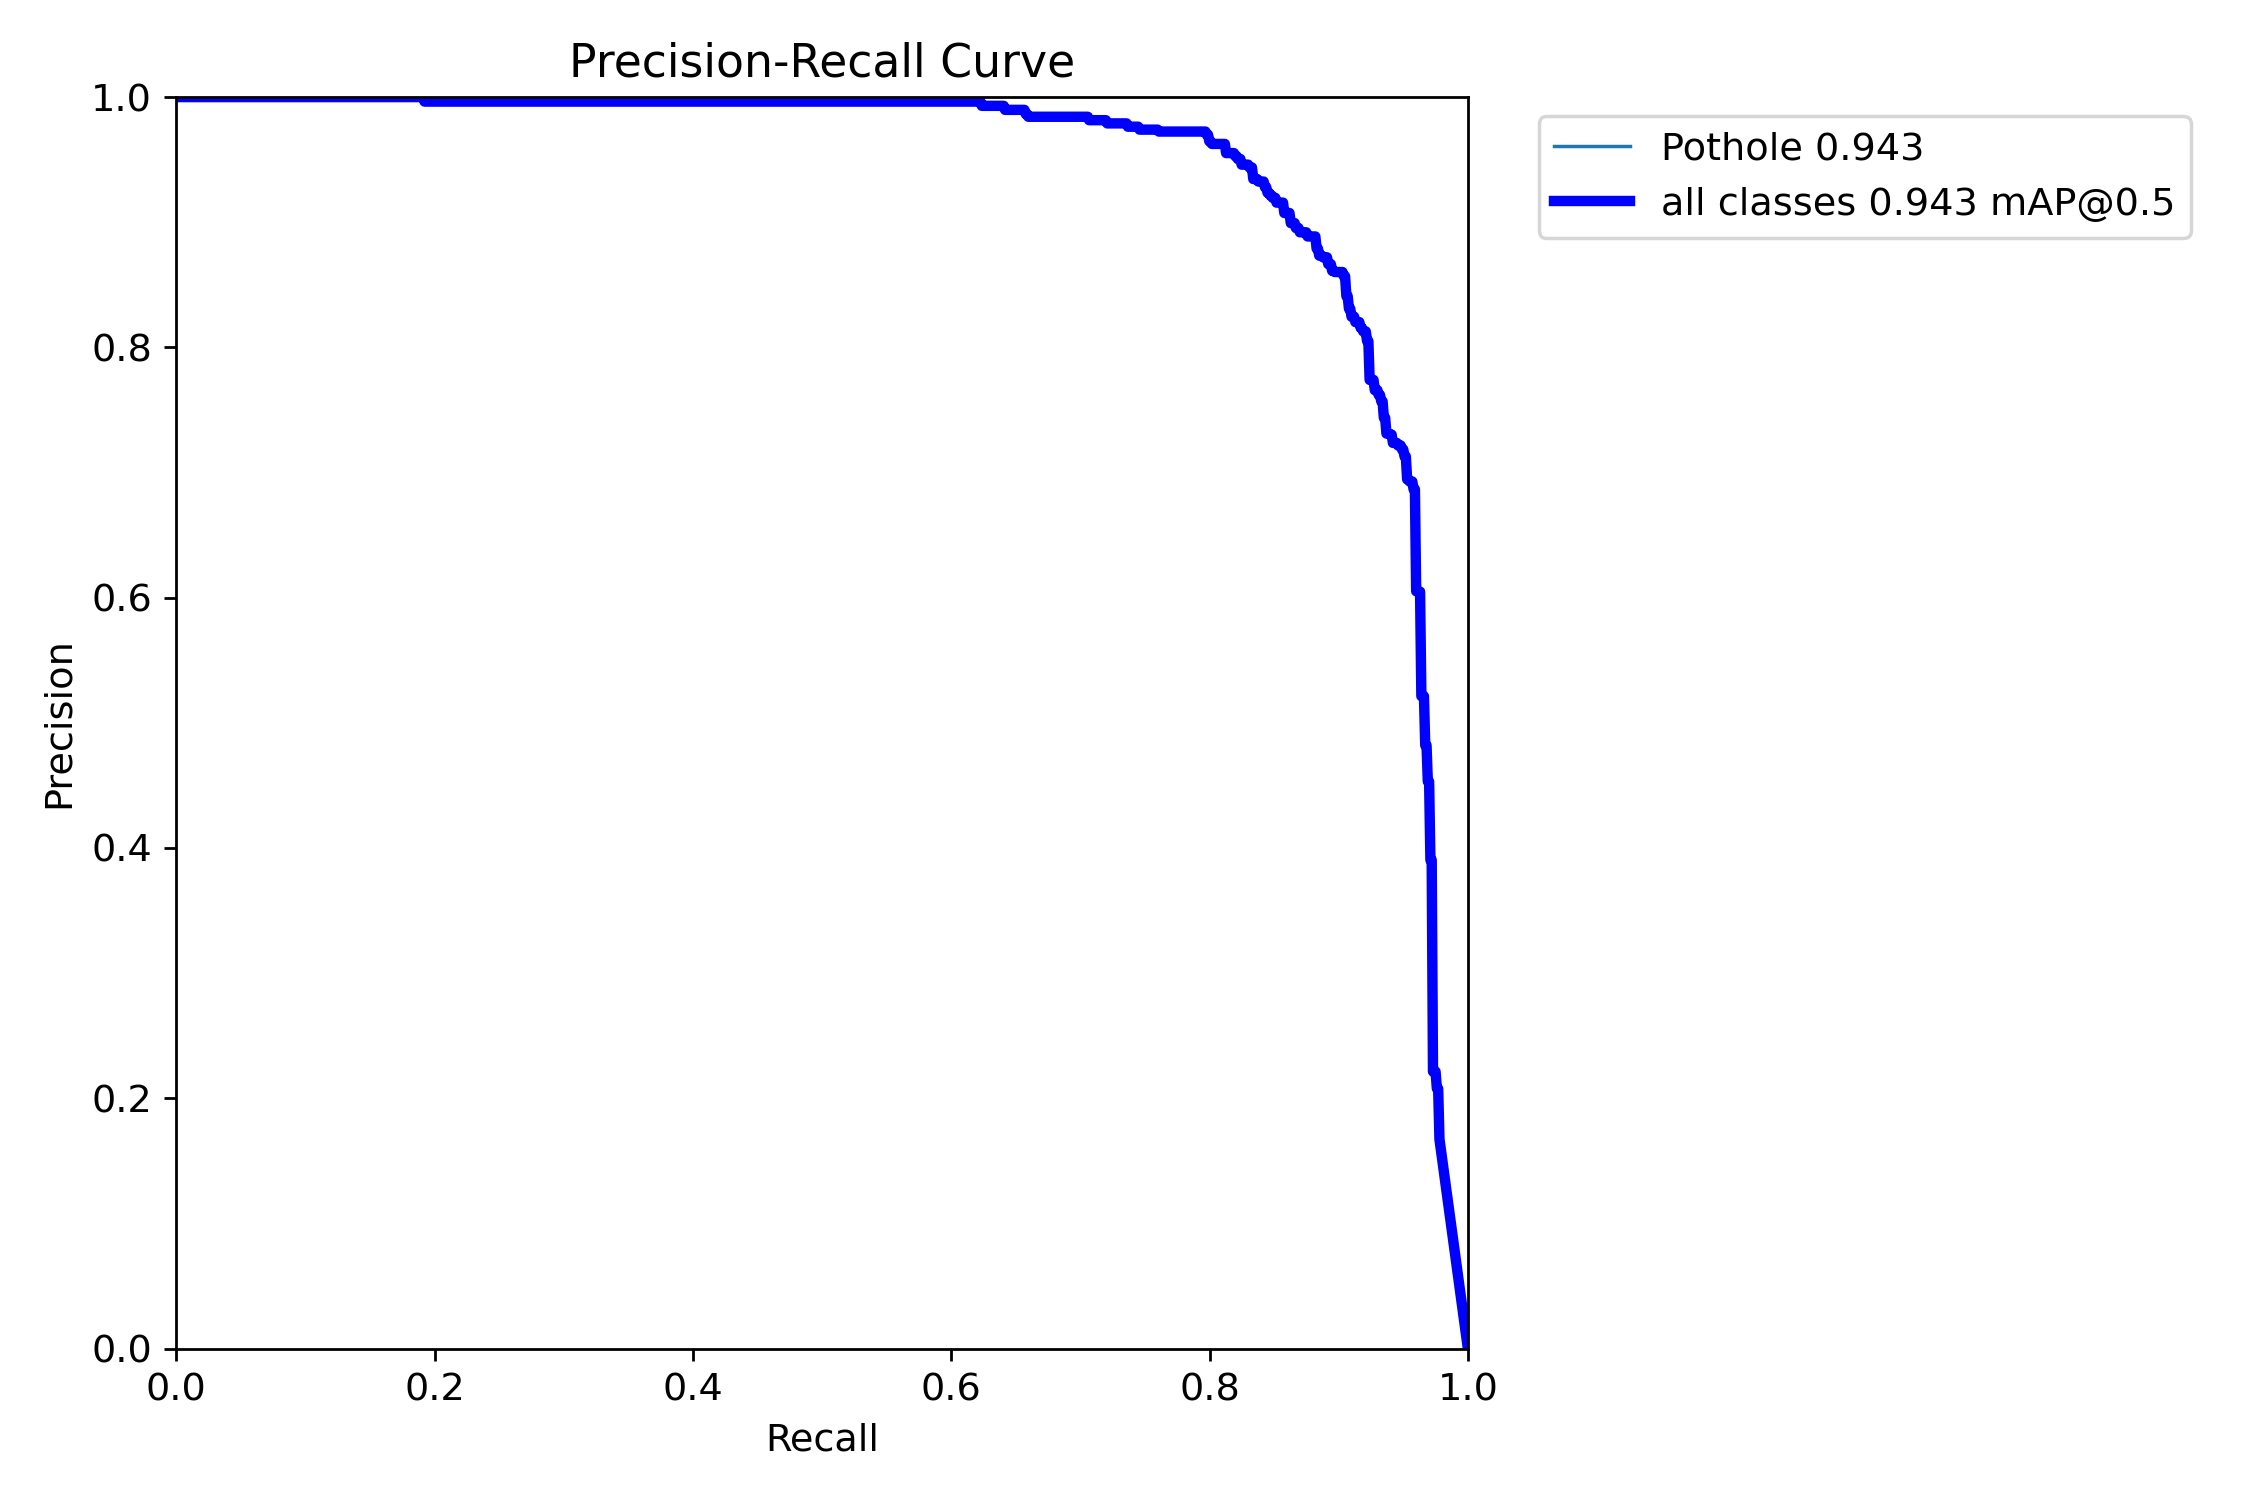

In [11]:
Image(prefix + "BoxPR_curve.png")

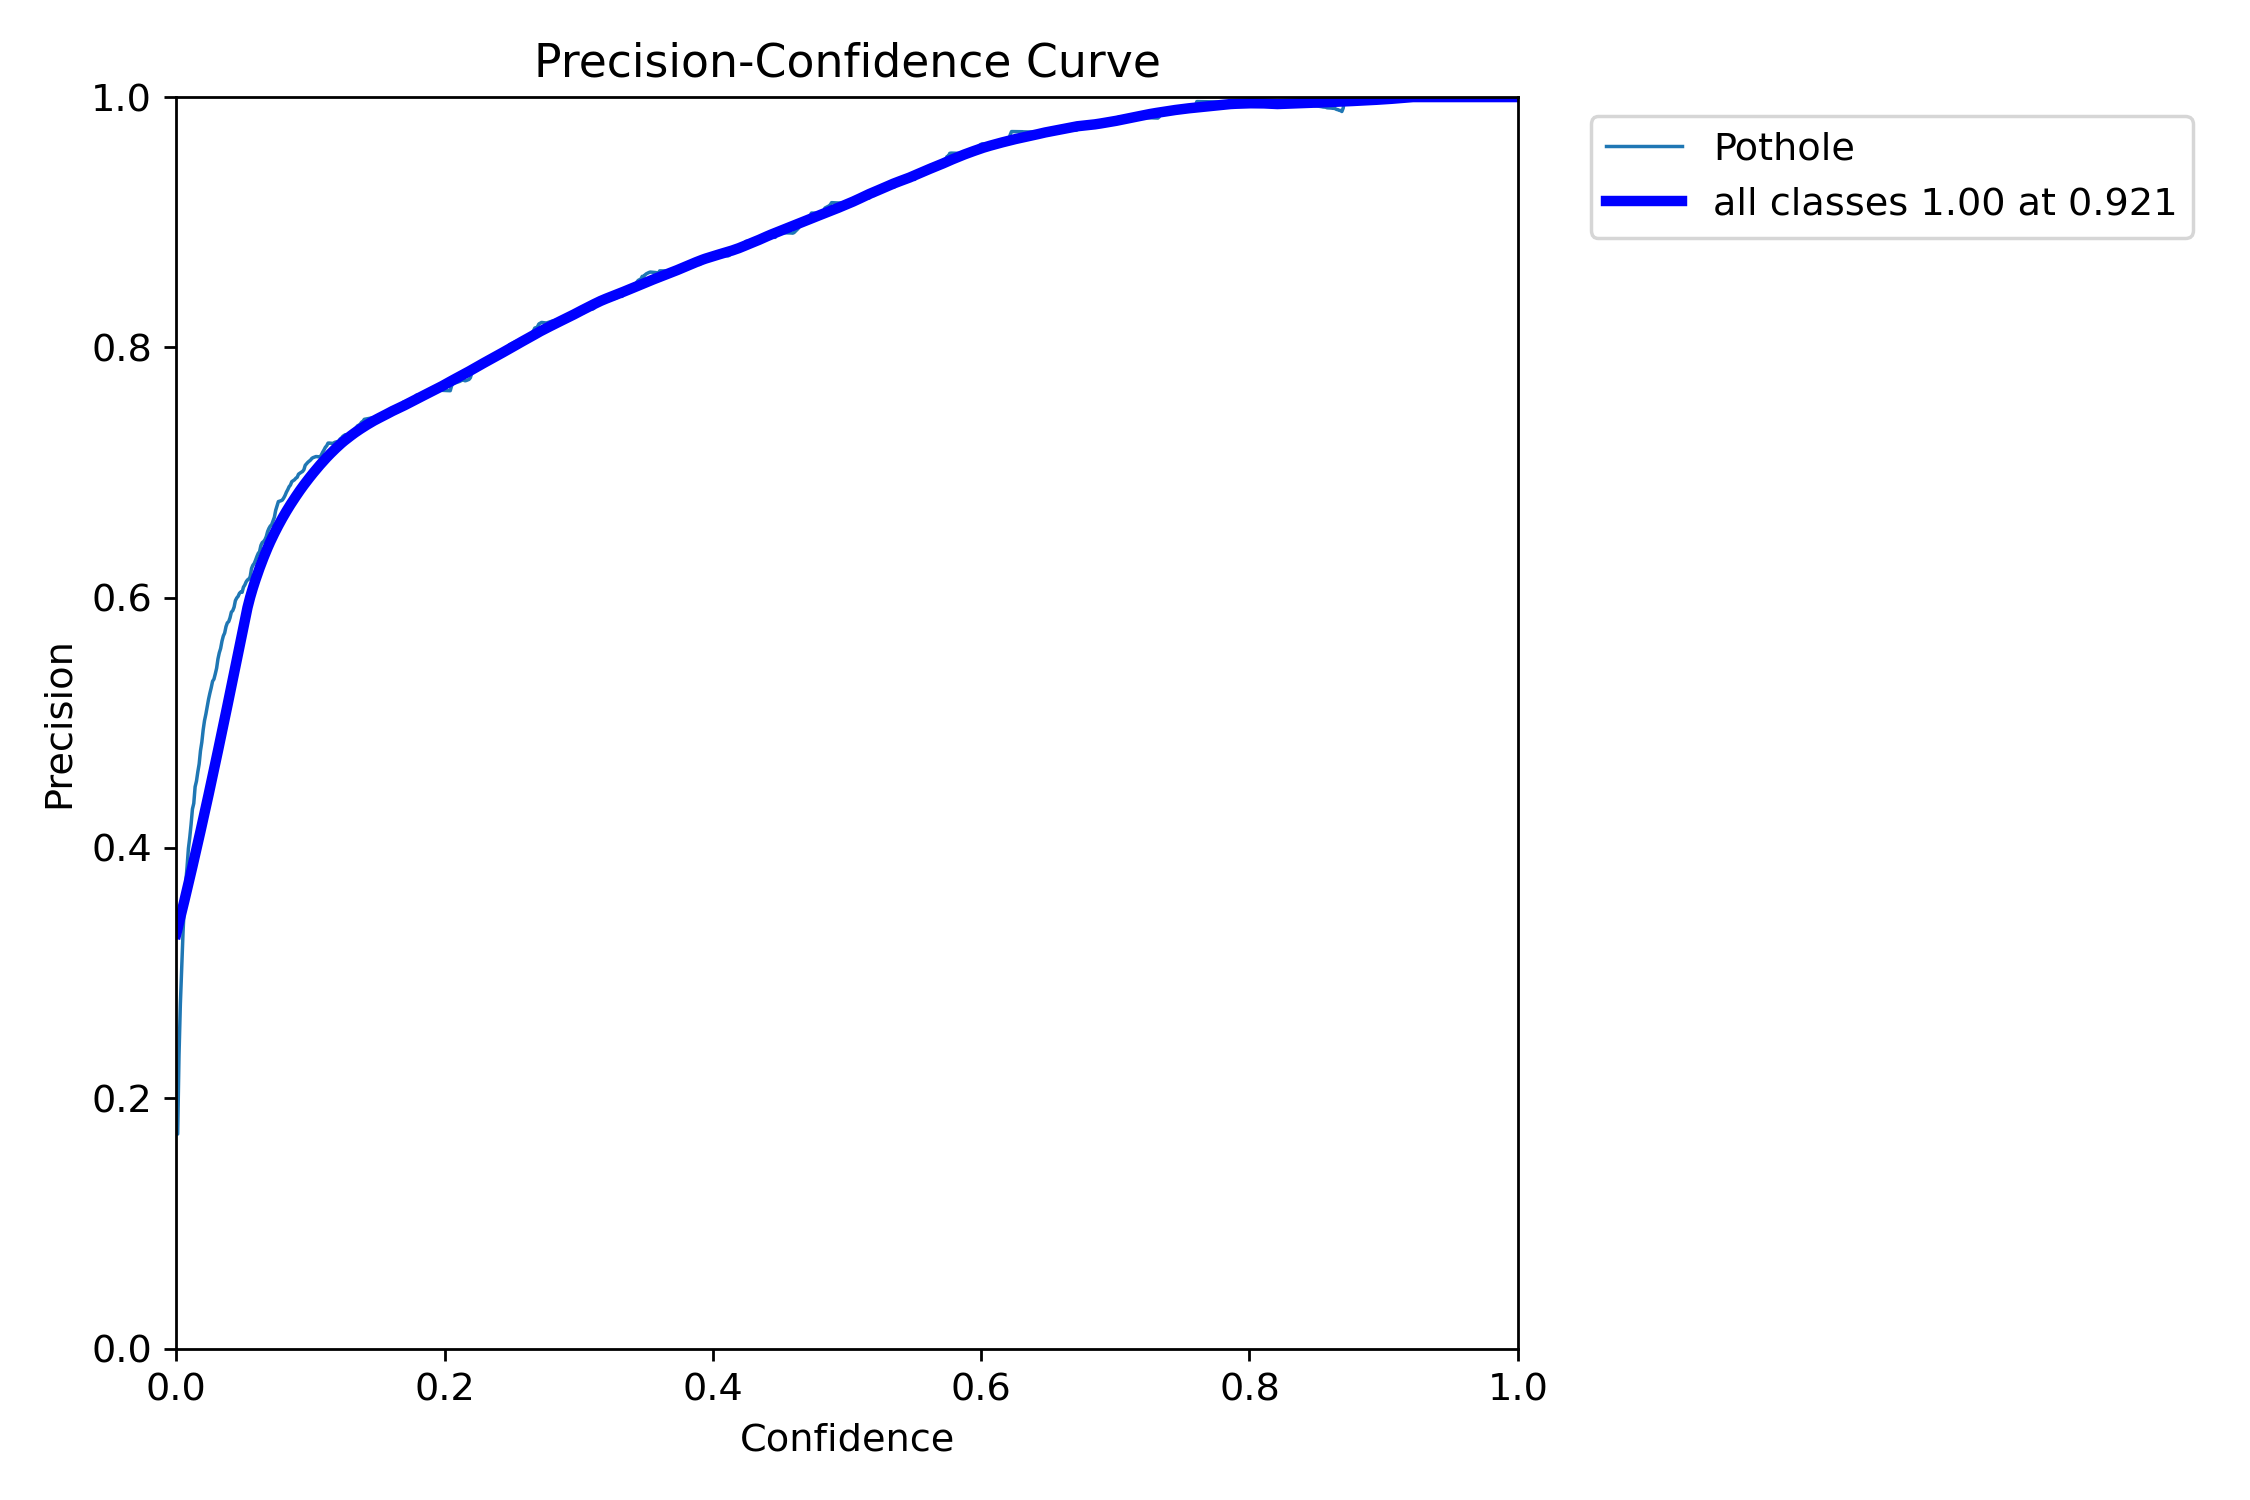

In [13]:
ext = ".png"
Image(prefix + "BoxP_curve" + ext)

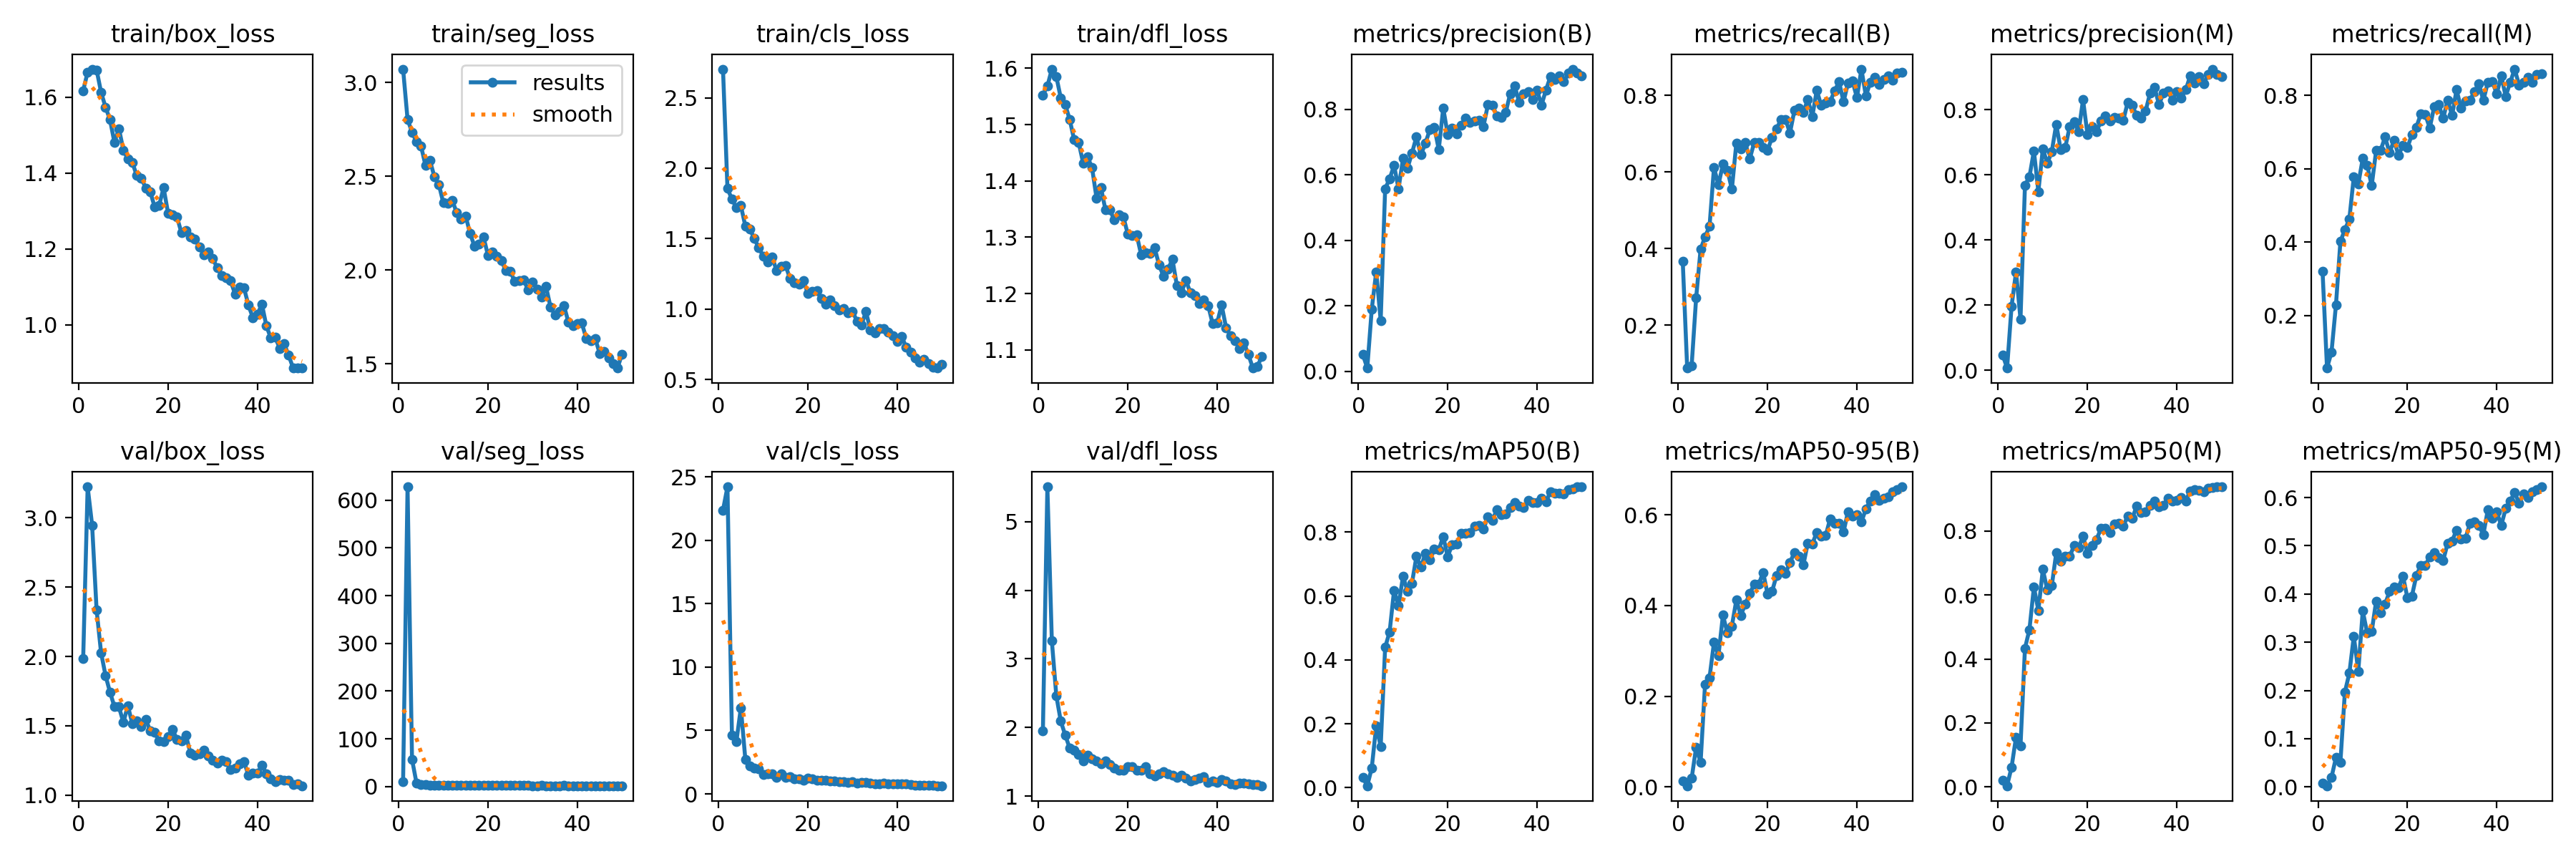

In [14]:
Image(prefix + "results" + ext)

Once the model is trained and happy with the results save the model somewhere so it can be used into an application.  I will move the model on my google drives for now

Steps
- mount the gdrive
- move command to move the model

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
# Move models to my drive for re-use in other applications
!mv /content/runs/segment/train/weights/best.pt /content/drive/MyDrive/YOLO11_custom_trained_models/potholes_custom_model/

In [19]:
!gdown "https://drive.google.com/uc?id=1iMitK9VCUWmBcZiiEPHK1d2pydALof6s&confirm=t"

Downloading...
From: https://drive.google.com/uc?id=1iMitK9VCUWmBcZiiEPHK1d2pydALof6s&confirm=t
To: /content/demo.mp4
100% 4.39M/4.39M [00:00<00:00, 31.7MB/s]


In [20]:
# test the model
results = model.predict(source = "/content/demo.mp4", save = True, conf = 0.25, iou = 0.3)


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/324) /content/demo.mp4: 384x640 3 Potholes, 65.6ms
video 1/1 (frame 2/324) /content/demo.mp4: 384x640 3 Potholes, 16.4ms
video 1/1 (frame 3/324) /content/demo.mp4: 384x640 4 Potholes, 13.9ms
video 1/1 (frame 4/324) /content/demo.mp4: 384x640 3 Potholes, 14.5ms
video 1/1 (frame 5/324) /content/demo.mp4: 384x640 4 Potholes, 13.9ms
video 1/1 (frame 6/324) /content/demo.mp4: 384x640 3 Potholes, 19.2ms
video 1/1 (frame 7/324) /content/dem

In [22]:
from IPython.display import HTML
from base64 import b64encode
import os

# Input video path
save_path = '/content/runs/segment/train2/demo.avi'

# Compressed video path
compressed_path = "/content/result_compressed.mp4"

os.system(f"ffmpeg -i {save_path} -vcodec libx264 {compressed_path}")

# Show video
mp4 = open(compressed_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)